In [1]:
import tensorflow as tf

print("TensorFlow Verion: ", tf.__version__)

TensorFlow Verion:  2.21.0


In [2]:
from tensorflow.keras import layers, models

model= models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation= "relu", input_shape= (224, 224, 3)))
model.add(layers.MaxPooling2D((2,2)))

model.summary()

c:\Users\SHARVANI SURESH\Desktop\Infotact-Crop-Disease-Detection\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
model.add(layers.Conv2D(64, (3,3), activation= "relu"))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(128, (3,3), activation= "relu"))
model.add(layers.MaxPooling2D((2,2)))

print("CNN feature extractor completed")

CNN feature extractor completed


In [4]:
# Flatten feature maps

model.add(
    layers.Flatten()
)


# Fully connected layer

model.add(
    layers.Dense(
        128,
        activation="relu"
    )
)


# Dropout to reduce overfitting

model.add(
    layers.Dropout(
        0.5
    )
)

# Output layer for 3 classes

model.add(
    layers.Dense(
        3,
        activation="softmax"
    )
)


print("CNN classification head completed")

CNN classification head completed


In [5]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


print("Early stopping configured")

Early stopping configured


In [7]:
import numpy as np


X_train = np.random.rand(
    30,
    224,
    224,
    3
)


y_train = tf.keras.utils.to_categorical(
    np.random.randint(0,3,30),
    3
)


history = model.fit(
    X_train,
    y_train,
    epochs=3,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3333 - loss: 1.1360 - val_accuracy: 0.6667 - val_loss: 2.2292
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 918ms/step - accuracy: 0.3750 - loss: 3.2129 - val_accuracy: 0.1667 - val_loss: 7.4295
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4583 - loss: 4.3486 - val_accuracy: 0.1667 - val_loss: 2.5007


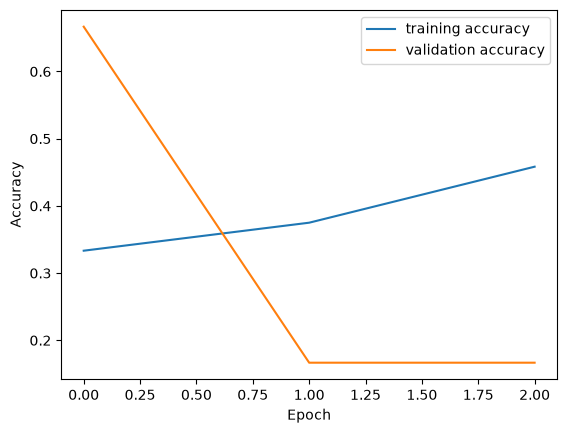

In [8]:
import matplotlib.pyplot as plt


plt.plot(
    history.history["accuracy"],
    label="training accuracy"
)


plt.plot(
    history.history["val_accuracy"],
    label="validation accuracy"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()